In [1]:
import radiate as rd
import polars as pl

rd.random.seed(67123)


In [2]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])


In [3]:
target_species = 4.0
rolling = int(target_species)

spec_count_signal = rd.select("count.species").rolling(rolling).mean() / target_species
spec_dist_signal = (
    rd.select("species.distance").mean().rolling(rolling).mean() / target_species
)
spec_thresh_signal = rd.select("species.threshold").rolling(rolling).mean()
spec_evenness_signal = rd.select("species.evenness").rolling(rolling).mean()

distance_signal = (
    (rd.lit(0.9) * spec_count_signal)
    + (rd.lit(0.4) * spec_dist_signal)
    + (rd.lit(0.2) * spec_thresh_signal)
    + (rd.lit(0.1) * spec_evenness_signal)
).clamp(0.01, 10.0)

distance_signal_mean = distance_signal.mean()
species_count_mean = rd.select("count.species").mean().rolling(10).mean()

In [4]:
collector = rd.MetricCollector()

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .diversity(rd.NeatDistance(), distance_signal)
    .metrics(
        distance_signal_mean=distance_signal_mean,
        species_count_mean=species_count_mean,
    )
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)


2026-05-08T04:11:15.526232Z  INFO Epoch 1    | Score:   2.0038 | Time: 485.71µs
2026-05-08T04:11:15.526405Z  INFO Epoch 2    | Score:   2.0038 | Time: 613.88µs
2026-05-08T04:11:15.526572Z  INFO Epoch 3    | Score:   1.6821 | Time: 743.79µs
2026-05-08T04:11:15.526712Z  INFO Epoch 4    | Score:   1.6821 | Time: 853.42µs
2026-05-08T04:11:15.526882Z  INFO Epoch 5    | Score:   1.6821 | Time: 959.83µs
2026-05-08T04:11:15.527024Z  INFO Epoch 6    | Score:   1.6821 | Time: 1.07ms
2026-05-08T04:11:15.527195Z  INFO Epoch 7    | Score:   1.6821 | Time: 1.21ms
2026-05-08T04:11:15.527372Z  INFO Epoch 8    | Score:   1.6821 | Time: 1.34ms
2026-05-08T04:11:15.527839Z  INFO Epoch 9    | Score:   1.6821 | Time: 1.72ms
2026-05-08T04:11:15.528040Z  INFO Epoch 10   | Score:   1.6821 | Time: 1.87ms
2026-05-08T04:11:15.528230Z  INFO Epoch 11   | Score:   1.6821 | Time: 2.02ms
2026-05-08T04:11:15.528422Z  INFO Epoch 12   | Score:   1.6821 | Time: 2.18ms
2026-05-08T04:11:15.528618Z  INFO Epoch 13   | Score: 

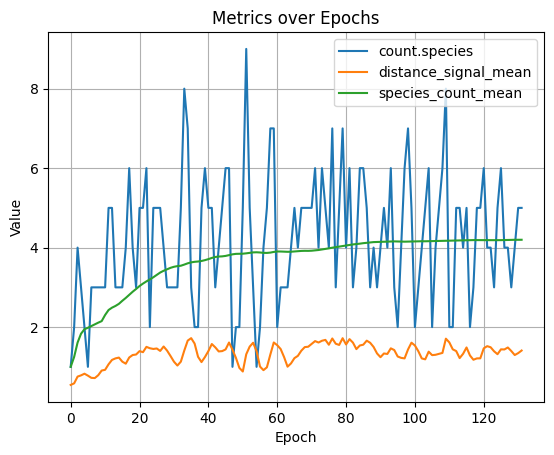

In [5]:
collector.plot(
    # "species.threshold", "count.species", "rate.diversity", "species.evenness"
    "count.species",
    "distance_signal_mean",
    "species_count_mean",
)


In [6]:
df = collector.to_polars()
df.filter(pl.col("name") == "count.species")

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,version,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.species""",1.0,1.0,1.0,0.0,0.0,NaN,1.0,1.0,1,null,null,null,null,null,null,0,1,"[""species"", ""statistic""]"
"""count.species""",2.0,3.0,1.5,0.707107,0.5,NaN,1.0,2.0,2,null,null,null,null,null,null,1,1,"[""species"", ""statistic""]"
"""count.species""",4.0,7.0,2.333333,1.527525,2.333333,8.049846,1.0,4.0,3,null,null,null,null,null,null,2,1,"[""species"", ""statistic""]"
"""count.species""",3.0,10.0,2.5,1.290994,1.666667,-0.000001,1.0,4.0,4,null,null,null,null,null,null,3,1,"[""species"", ""statistic""]"
"""count.species""",2.0,12.0,2.4,1.140175,1.3,75.000107,1.0,4.0,5,null,null,null,null,null,null,4,1,"[""species"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""count.species""",4.0,538.0,4.203125,1.603929,2.572589,0.495529,1.0,9.0,128,null,null,null,null,null,null,127,1,"[""species"", ""statistic""]"
"""count.species""",3.0,541.0,4.193799,1.601159,2.563711,0.526515,1.0,9.0,129,null,null,null,null,null,null,128,1,"[""species"", ""statistic""]"
"""count.species""",4.0,545.0,4.192307,1.595032,2.544127,0.538419,1.0,9.0,130,null,null,null,null,null,null,129,1,"[""species"", ""statistic""]"


In [7]:
df = collector.to_polars()
df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,version,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""step.speciate.time""",0.000067,0.000067,0.000067,0.0,0.0,NaN,0.000067,0.000067,1,66µs,66µs,0µs,66µs,66µs,0µs,0,1,"[""time"", ""step""]"
"""mutate.graph""",24.0,24.0,24.0,0.0,0.0,NaN,24.0,24.0,1,null,null,null,null,null,null,0,1,"[""statistic""]"
"""lineage.events""",8.0,8.0,8.0,0.0,0.0,NaN,8.0,8.0,1,null,null,null,null,null,null,0,1,"[""age"", ""statistic"", ""lineage""]"
"""alter.cross_family""",0.0,0.0,0.0,0.0,0.0,NaN,3.4028e38,-3.4028e38,0,null,null,null,null,null,null,0,0,"[""alterer"", ""distribution"", ""lineage""]"
"""invalid.species""",0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1,null,null,null,null,null,null,0,1,"[""species"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""size.genome""",28.0,2812.0,28.120001,0.755853,0.571313,0.0,27.0,30.0,100,null,null,null,null,null,null,131,100,"[""distribution""]"
"""crossover.graph.rate""",0.05,27.550001,0.05,0.0,0.0,0.0,0.05,0.05,551,null,null,null,null,null,null,131,5,"[""alterer"", ""crossover"", … ""rate""]"
"""rate.carryover""",0.118421,31.133228,0.235858,0.133092,0.017713,0.0,0.0,0.851064,132,null,null,null,null,null,null,131,1,"[""derived"", ""statistic"", ""rate""]"


In [8]:
print(result.index())
last_version = df.select("version").max().item()
last_version

132


131